Лаб №4.

In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
import mpl_toolkits.mplot3d
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.cluster import MiniBatchKMeans
from tqdm import tqdm
import time
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
from sklearn.preprocessing import LabelEncoder

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
dataset = pd.read_csv('/content/drive/MyDrive/paddydataset.csv')
print("Информация о датасете:")
dataset.head()

Информация о датасете:


,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


Пункт 1.

In [25]:
vals = dataset["Soil Types"].unique()
vals

array(['alluvial', 'clay'], dtype=object)

In [26]:
cols_for_clusters = ['Hectares ','Seedrate(in Kg)','LP_Mainfield(in Tonnes)','Nursery area (Cents)']
df= dataset[cols_for_clusters].copy()
df.head()

,Hectares,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery area (Cents)
0,6,150,75.0,120
1,6,150,75.0,120
2,6,150,75.0,120
3,6,150,75.0,120
4,6,150,75.0,120


In [27]:
X = df
y, yvals = pd.factorize(dataset["Soil Types"])
print(f"Уникальные классы: {yvals}")
print(f"Закодированные метки (первые 5): {y[:5]}")

Уникальные классы: Index(['alluvial', 'clay'], dtype='object')
Закодированные метки (первые 5): [0 1 0 1 0]


Пункт 2. K-Means

Точные названия колонок в датасете:
  'Hectares '
  'Seedrate(in Kg)'
  'LP_Mainfield(in Tonnes)'
  'Nursery area (Cents)'
  'class'

✓ Колонка с урожайностью не найдена по названию
✓ Используем последнюю числовую колонку: 'Nursery area (Cents)'
✓ Классы созданы на основе 'Nursery area (Cents)'

✓ Признаки для кластеризации: ['Hectares ', 'Seedrate(in Kg)', 'LP_Mainfield(in Tonnes)']
✓ Классы: ['High' 'Low' 'Medium']

✓ Отображаем ВСЕ точки: 2789 точек


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (6) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/tmp/ipykernel_15835/4226837213.py:135: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


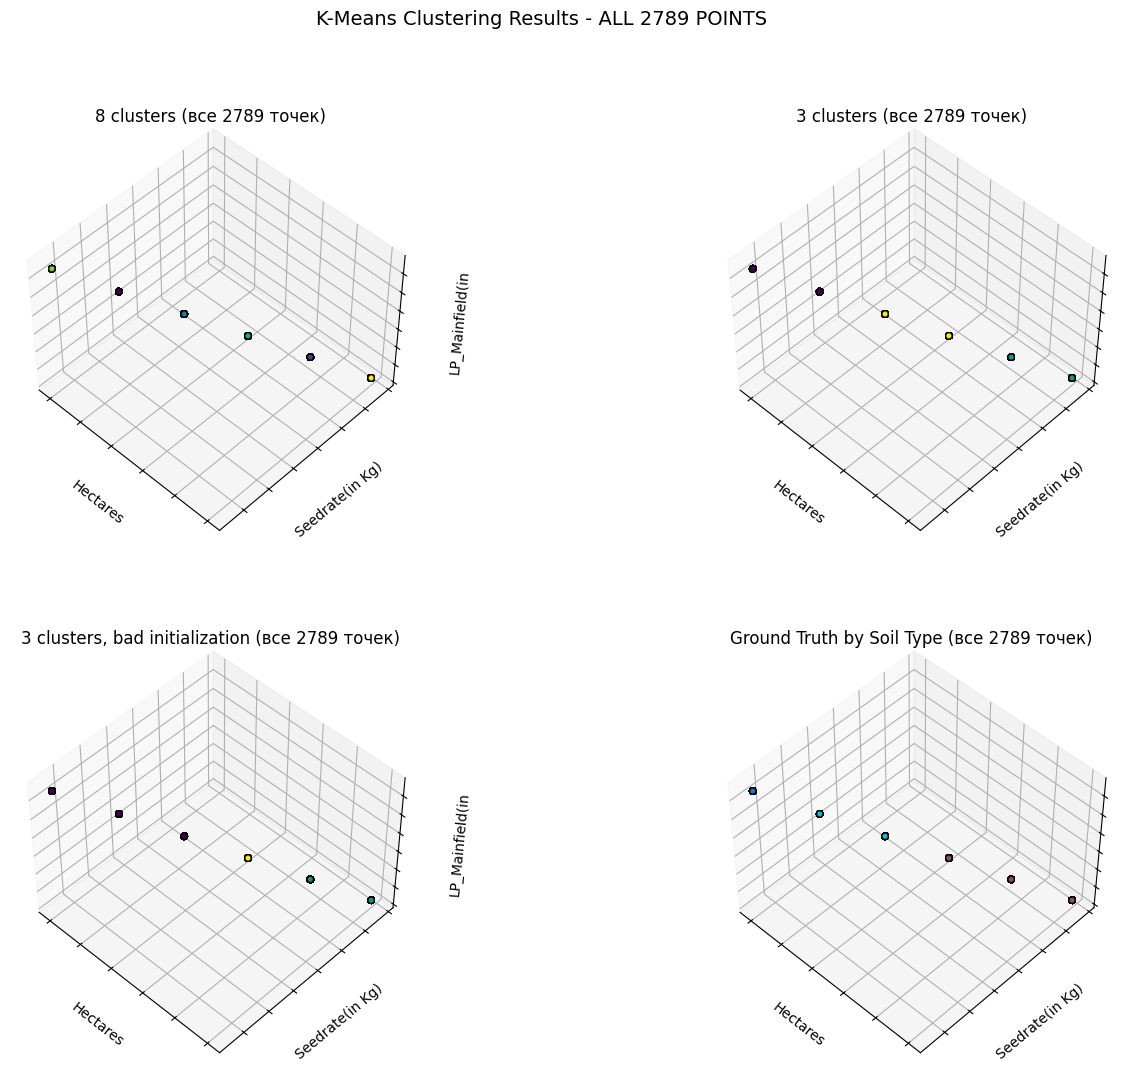

In [33]:
print("Точные названия колонок в датасете:")
for col in df.columns:
    print(f"  '{col}'")

yield_col = None
for col in df.columns:
    if 'yield' in col.lower() or 'Paddy' in col or 'Yield' in col:
        yield_col = col
        print(f"\n✓ Найдена колонка с урожайностью: '{yield_col}'")
        break

if yield_col is None:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if numeric_cols:
        yield_col = numeric_cols[-1]
        print(f"\n✓ Колонка с урожайностью не найдена по названию")
        print(f"✓ Используем последнюю числовую колонку: '{yield_col}'")
    else:
        raise ValueError("Нет числовых колонок в датасете!")

try:
    df['class'] = pd.qcut(df[yield_col], q=3, labels=['Low', 'Medium', 'High'])
    print(f"✓ Классы созданы на основе '{yield_col}'")
except Exception as e:
    print(f"Ошибка при создании классов: {e}")
    df['class'] = pd.cut(df[yield_col], bins=3, labels=['Low', 'Medium', 'High'])
    print("✓ Использован альтернативный метод разбиения на классы")

feature_cols = []
possible_features = ['Hectares ', 'Seedrate(in Kg)', 'LP_Mainfield(in Tonnes)',
                      'Urea_40Days', 'Pest_60Day(in ml)', 'Trash(in bundles)']

for col in possible_features:
    if col in df.columns:
        feature_cols.append(col)
        if len(feature_cols) == 3:
            break

if len(feature_cols) < 3:
    print(f"\nВНИМАНИЕ: Найдено только {len(feature_cols)} признаков из запрошенных")
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if yield_col in numeric_cols:
        numeric_cols.remove(yield_col)
    feature_cols = numeric_cols[:3]
    print(f"✓ Используем первые 3 числовые колонки: {feature_cols}")

X = df[feature_cols].copy()
print(f"\n✓ Признаки для кластеризации: {feature_cols}")

le = LabelEncoder()
y_encoded = le.fit_transform(df['class'])
print(f"✓ Классы: {le.classes_}")

X_sample = X
y_sample = y_encoded
soil_col = 'Soil Types' if 'Soil Types' in df.columns else None
soil_sample = df[soil_col] if soil_col else None
print(f"\n✓ Отображаем ВСЕ точки: {len(X)} точек")

estimators = [
    ("k_means_8", KMeans(n_clusters=8, random_state=42, n_init=10)),
    ("k_means_3", KMeans(n_clusters=3, random_state=42, n_init=10)),
    ("k_means_bad_init", KMeans(n_clusters=3, n_init=1, init="random", random_state=42)),
]

fig = plt.figure(figsize=(16, 12))
titles = ["8 clusters", "3 clusters", "3 clusters, bad initialization"]

axis_labels = [col.strip()[:15] for col in feature_cols[:3]]

for idx, ((name, est), title) in enumerate(zip(estimators, titles)):
    ax = fig.add_subplot(2, 2, idx + 1, projection="3d", elev=48, azim=134)
    est.fit(X_sample)
    labels_sample = est.labels_

    scatter = ax.scatter(
        X_sample.iloc[:, 0],
        X_sample.iloc[:, 1],
        X_sample.iloc[:, 2],
        c=labels_sample.astype(float),
        edgecolor="k",
        s=20,
        alpha=0.7,
        cmap='viridis'
    )
    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
    ax.zaxis.set_ticklabels([])
    ax.set_xlabel(axis_labels[0], fontsize=10)
    ax.set_ylabel(axis_labels[1], fontsize=10)
    ax.set_zlabel(axis_labels[2], fontsize=10)
    ax.set_title(f"{title} (все {len(X_sample)} точек)", fontsize=12)
ax = fig.add_subplot(2, 2, 4, projection="3d", elev=48, azim=134)

if soil_sample is not None:
    unique_soil_types = np.unique(soil_sample)[:8]
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_soil_types)))

    for i, soil_type in enumerate(unique_soil_types):
        mask = soil_sample == soil_type
        ds_sample = X_sample[mask]
        if len(ds_sample) > 10:
            ax.text3D(
                ds_sample.iloc[:, 0].mean(),
                ds_sample.iloc[:, 1].mean(),
                ds_sample.iloc[:, 2].mean(),
                str(soil_type)[:12],
                horizontalalignment="center",
                bbox=dict(alpha=0.3, edgecolor="w", facecolor=colors[i]),
                fontsize=7,
                color='white'
            )

scatter = ax.scatter(
    X_sample.iloc[:, 0],
    X_sample.iloc[:, 1],
    X_sample.iloc[:, 2],
    c=y_sample,
    edgecolor="k",
    s=20,
    alpha=0.7,
    cmap='tab10'
)

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel(axis_labels[0], fontsize=10)
ax.set_ylabel(axis_labels[1], fontsize=10)
ax.set_zlabel(axis_labels[2], fontsize=10)
ax.set_title(f"Ground Truth by Soil Type (все {len(X_sample)} точек)", fontsize=12)

plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.suptitle(f"K-Means Clustering Results - ALL {len(X_sample)} POINTS", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

Пункт 3. Метрики

In [34]:
n_clusters = np.arange(2, 21)

ЗАПУСК ОПТИМИЗИРОВАННОГО АНАЛИЗА...

АНАЛИЗ K-MEANS (только Silhouette)
Размер датасета: 2789 строк × 3 признаков
Используем выборку 2789 точек для расчета метрик


Анализ кластеров:   5%|▌         | 1/19 [00:00<00:06,  2.85it/s]

   k=2: silhouette=0.6907


Анализ кластеров:  11%|█         | 2/19 [00:00<00:06,  2.71it/s]

   k=3: silhouette=0.6913


...

   k=16: silhouette=1.0000
   k=17: silhouette=1.0000


Анализ кластеров:  95%|█████████▍| 18/19 [00:05<00:00,  5.02it/s]

   k=18: silhouette=1.0000
   k=19: silhouette=1.0000


Анализ кластеров: 100%|██████████| 19/19 [00:05<00:00,  3.46it/s]


   k=20: silhouette=1.0000

РЕЗУЛЬТАТЫ
Время выполнения: 5.5 сек (0.1 мин)

Лучшее k = 6
Silhouette score = 1.0000


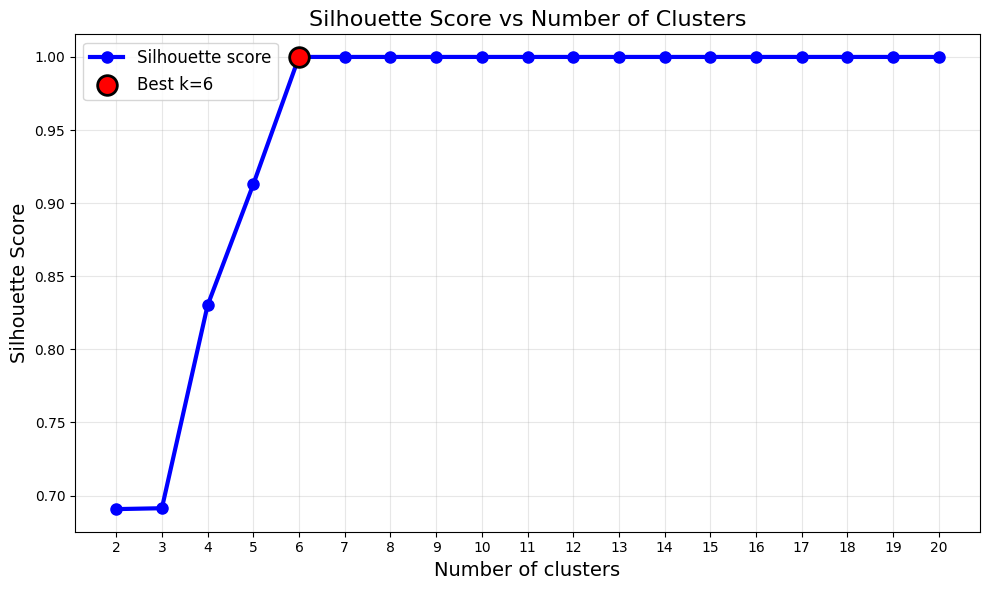


ФИНАЛЬНАЯ КЛАСТЕРИЗАЦИЯ С k=6

Кластеризация завершена!

Распределение по кластерам:
   Кластер 0: 850 точек (30.5%)
   Кластер 1: 399 точек (14.3%)
   Кластер 2: 600 точек (21.5%)
   Кластер 3: 490 точек (17.6%)
   Кластер 4: 250 точек (9.0%)
   Кластер 5: 200 точек (7.2%)

Центры кластеров (первые 5):
   Кластер 0: Hectares =5.00, Seedrate(in Kg)=125.00, LP_Mainfield(in Tonnes)=62.50
   Кластер 1: Hectares =3.00, Seedrate(in Kg)=75.00, LP_Mainfield(in Tonnes)=37.50
   Кластер 2: Hectares =1.00, Seedrate(in Kg)=25.00, LP_Mainfield(in Tonnes)=12.50
   Кластер 3: Hectares =4.00, Seedrate(in Kg)=100.00, LP_Mainfield(in Tonnes)=50.00
   Кластер 4: Hectares =2.00, Seedrate(in Kg)=50.00, LP_Mainfield(in Tonnes)=25.00


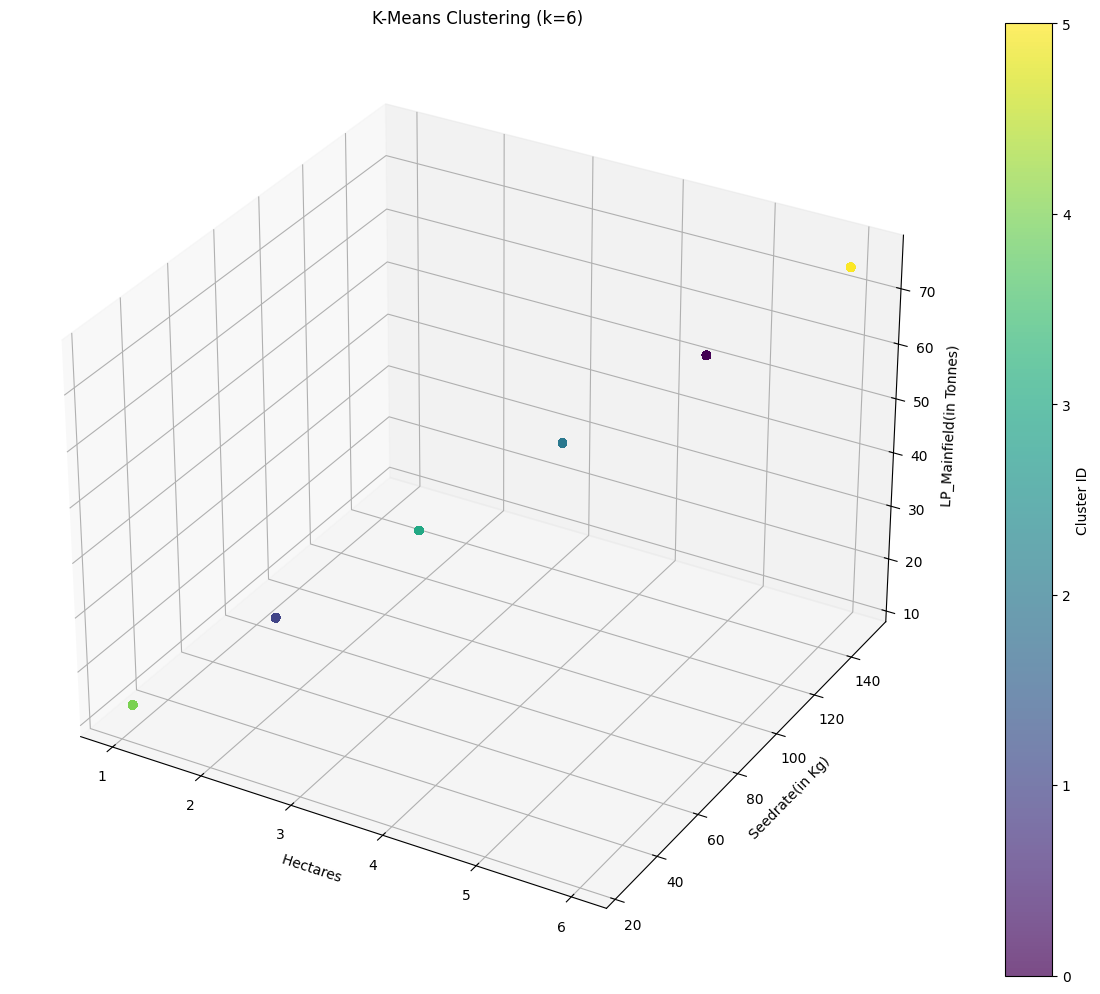

In [38]:
def evaluate_kmeans_silhouette(X, k_range=range(2, 21), sample_size=5000):
    """
    Анализ K-Means с метрикой Silhouette для выбора оптимального k
    """
    print(f"АНАЛИЗ K-MEANS (только Silhouette)")
    print(f"Размер датасета: {len(X)} строк × {X.shape[1]} признаков")
    start_time = time.time()

    n_samples = min(sample_size, len(X))
    sample_idx = np.random.choice(len(X), n_samples, replace=False)

    if hasattr(X, 'iloc'):
        X_sample = X.iloc[sample_idx].values
        X_full = X.values if hasattr(X, 'values') else X
    else:
        X_sample = X[sample_idx]
        X_full = X

    print(f"Используем выборку {n_samples} точек для расчета метрик")

    best_k = 0
    best_silhouette = -1
    best_centers = None
    silhouette_scores = []

    for k in tqdm(list(k_range), desc="Анализ кластеров"):
        kmeans = MiniBatchKMeans(
            n_clusters=k,
            batch_size=min(1024, len(X)//20),
            max_iter=100,
            n_init=5,
            random_state=42
        )
        kmeans.fit(X_full)
        y_pred_full = kmeans.predict(X_full)
        y_pred_sample = y_pred_full[sample_idx]

        sil = metrics.silhouette_score(X_sample, y_pred_sample)
        silhouette_scores.append(sil)

        if sil > best_silhouette:
            best_silhouette = sil
            best_k = k
            best_centers = kmeans.cluster_centers_

        print(f"   k={k}: silhouette={sil:.4f}")

    elapsed = time.time() - start_time
    print(f"\nРЕЗУЛЬТАТЫ")
    print(f"Время выполнения: {elapsed:.1f} сек ({elapsed/60:.1f} мин)")
    print(f"\nЛучшее k = {best_k}")
    print(f"Silhouette score = {best_silhouette:.4f}")

    return best_k, best_silhouette, best_centers, silhouette_scores, list(k_range)

print("ЗАПУСК ОПТИМИЗИРОВАННОГО АНАЛИЗА...\n")

if hasattr(X, 'values'):
    X_for_clustering = X.values
else:
    X_for_clustering = X

best_k, best_sil, centers, sil_scores, k_vals = evaluate_kmeans_silhouette(
    X=X_for_clustering,
    k_range=range(2, 21),
    sample_size=5000
)

plt.figure(figsize=(10, 6))
plt.plot(k_vals, sil_scores, 'bo-', linewidth=3, markersize=8, label='Silhouette score')
plt.scatter(best_k, best_sil, color='red', s=200, zorder=5,
            edgecolor='black', linewidth=2, label=f'Best k={best_k}')
plt.xlabel('Number of clusters', size=14)
plt.ylabel('Silhouette Score', size=14)
plt.title('Silhouette Score vs Number of Clusters', size=16)
plt.xticks(k_vals, size=10)
plt.yticks(size=10)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nФИНАЛЬНАЯ КЛАСТЕРИЗАЦИЯ С k={best_k}")
final_kmeans = MiniBatchKMeans(
    n_clusters=best_k,
    batch_size=1024,
    max_iter=100,
    n_init=10,
    random_state=42
)
final_labels = final_kmeans.fit_predict(X_for_clustering)

print(f"\nКластеризация завершена!")
print(f"\nРаспределение по кластерам:")
unique, counts = np.unique(final_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    percentage = count / len(X) * 100
    print(f"   Кластер {cluster}: {count} точек ({percentage:.1f}%)")

feature_names = X.columns.tolist() if hasattr(X, 'columns') else [f'Feature_{i}' for i in range(X_for_clustering.shape[1])]

print(f"\nЦентры кластеров (первые 5):")
for i, center in enumerate(centers[:5]):
    center_str = ', '.join([f'{feature_names[j]}={center[j]:.2f}' for j in range(min(3, len(center)))])
    print(f"   Кластер {i}: {center_str}")

if len(X) <= 10000:
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection="3d")
    sample_size_display = min(2000, len(X))
    idx_display = np.random.choice(len(X), sample_size_display, replace=False)

    if hasattr(X, 'iloc'):
        X_display = X.iloc[idx_display]
    else:
        X_display = X[idx_display]

    labels_display = final_labels[idx_display]

    scatter = ax.scatter(
        X_display.iloc[:, 0] if hasattr(X_display, 'iloc') else X_display[:, 0],
        X_display.iloc[:, 1] if hasattr(X_display, 'iloc') else X_display[:, 1],
        X_display.iloc[:, 2] if hasattr(X_display, 'iloc') else X_display[:, 2],
        c=labels_display,
        cmap='viridis',
        s=30,
        alpha=0.7
    )

    ax.set_xlabel(feature_names[0], fontsize=10)
    ax.set_ylabel(feature_names[1], fontsize=10)
    ax.set_zlabel(feature_names[2], fontsize=10)
    ax.set_title(f'K-Means Clustering (k={best_k})', fontsize=12)
    plt.colorbar(scatter, label='Cluster ID')
    plt.tight_layout()
    plt.show()
else:
    print(f"\nПропускаем 3D визуализацию (слишком много точек: {len(X)})")

Используем 4 числовых признаков: ['Hectares ', 'Seedrate(in Kg)', 'LP_Mainfield(in Tonnes)', 'Nursery area (Cents)']...

Размер полного датасета: 2789 точек
Используем выборку: 1000 точек для дендрограммы


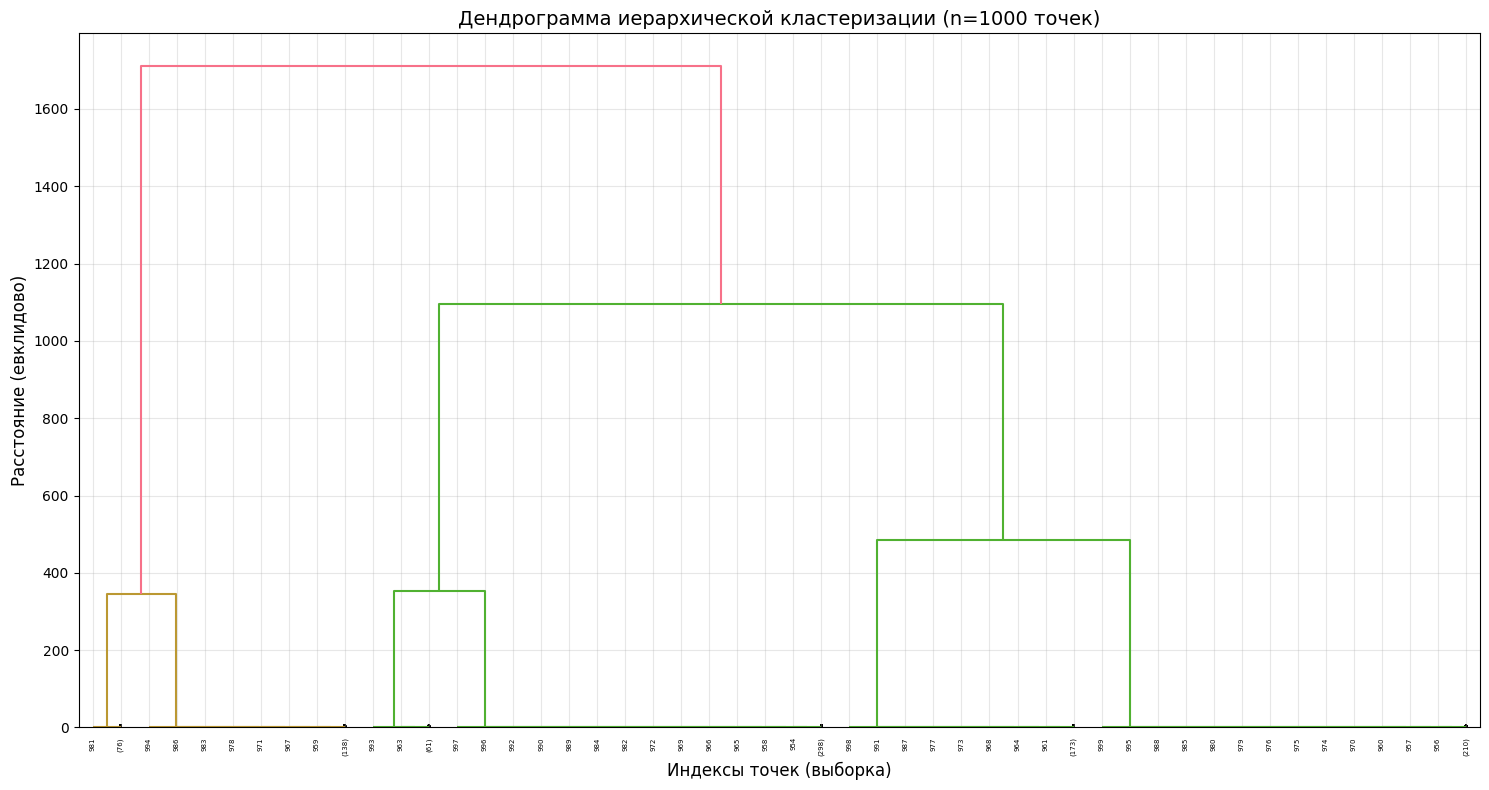

In [41]:
if 'df' in dir() and df is not None:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    target_col = None
    for col in numeric_cols:
        if 'yield' in col.lower() or 'Paddy' in col:
            target_col = col
            break

    if target_col and target_col in numeric_cols:
        numeric_cols.remove(target_col)
        print(f"Исключена колонка с урожайностью: '{target_col}'")

    data = df[numeric_cols].values
    print(f"Используем {len(numeric_cols)} числовых признаков: {numeric_cols[:5]}...")

elif 'dataset' in dir() and dataset is not None:
    numeric_cols = dataset.select_dtypes(include=[np.number]).columns
    data = dataset[numeric_cols].values
    print(f"Используем датасет 'dataset' с {len(numeric_cols)} числовыми признаками")
else:
    raise ValueError("Нет доступных данных (ни df, ни dataset)")

sample_size = min(1000, len(data))
print(f"\nРазмер полного датасета: {len(data)} точек")
print(f"Используем выборку: {sample_size} точек для дендрограммы")

np.random.seed(42)
idx = np.random.choice(len(data), sample_size, replace=False)
data_sample = data[idx]

plt.figure(figsize=(15, 8))
mergings = linkage(data_sample, method='ward')

dendrogram(mergings,
           leaf_rotation=90,
           leaf_font_size=5,
           truncate_mode='lastp',
           p=50,
           show_contracted=True)

plt.title(f'Дендрограмма иерархической кластеризации (n={sample_size} точек)', fontsize=14)
plt.xlabel('Индексы точек (выборка)', fontsize=12)
plt.ylabel('Расстояние (евклидово)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Размер данных: (2789, 3)
Признаки: ['Hectares ', 'Seedrate(in Kg)', 'LP_Mainfield(in Tonnes)']...

Результаты DBSCAN:
  EPS (радиус): 0.5
  Min samples: 12
  Количество кластеров: 6
  Количество шумовых точек: 0
  Всего точек: 2789


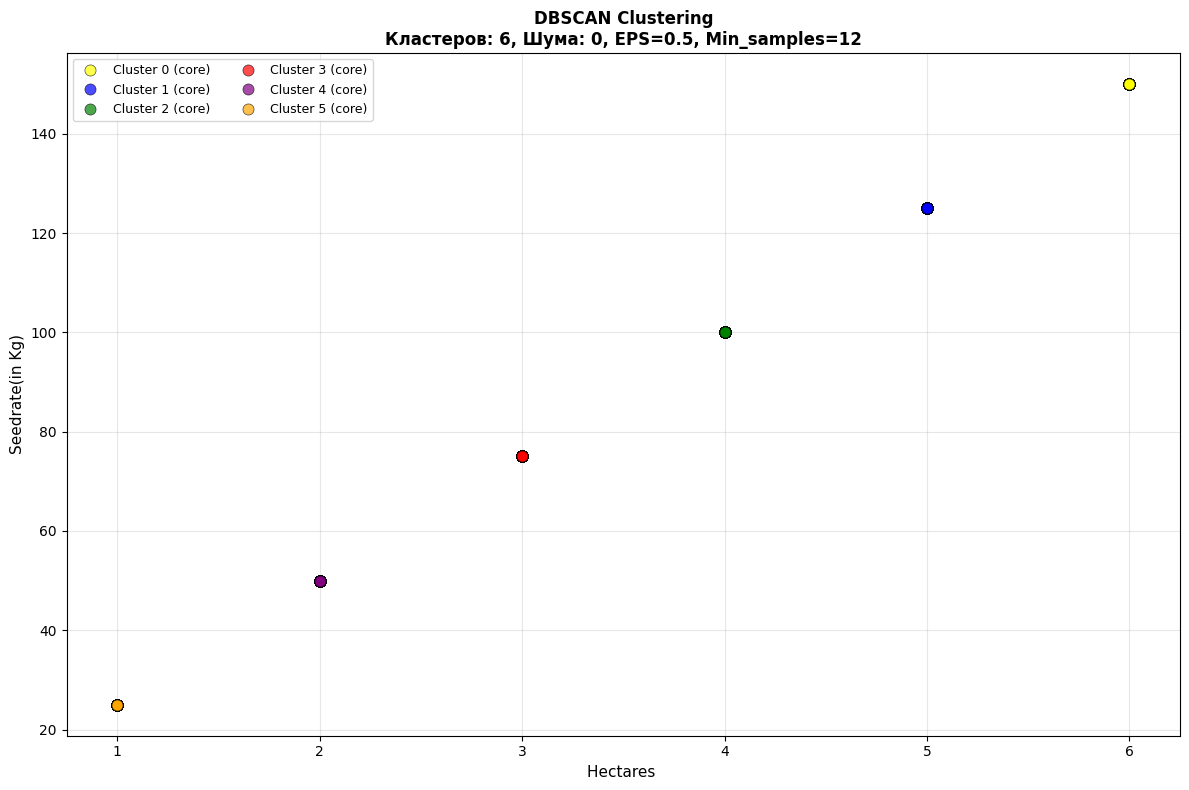

In [43]:
if hasattr(X, 'values'):
    X_array = X.values
    feature_names = X.columns.tolist()
else:
    X_array = X
    feature_names = [f'Feature_{i}' for i in range(X_array.shape[1])]

print(f"Размер данных: {X_array.shape}")
print(f"Признаки: {feature_names[:3]}...")

feature1_idx = 0
feature2_idx = 1
feature1_name = feature_names[feature1_idx] if len(feature_names) > feature1_idx else 'Feature 1'
feature2_name = feature_names[feature2_idx] if len(feature_names) > feature2_idx else 'Feature 2'

X_2d = X_array[:, [feature1_idx, feature2_idx]]

eps = 0.5
min_samples = 12

db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_2d)

core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

unique_labels = set(labels)
colors = ['yellow', 'blue', 'green', 'red', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive']

print(f"\nРезультаты DBSCAN:")
print(f"  EPS (радиус): {eps}")
print(f"  Min samples: {min_samples}")
print(f"  Количество кластеров: {n_clusters_}")
print(f"  Количество шумовых точек: {n_noise_}")
print(f"  Всего точек: {len(labels)}")

plt.figure(figsize=(12, 8))

for k, col in zip(sorted(unique_labels), colors[:len(unique_labels)]):
    if k == -1:
        col = 'black'
        label = 'Noise'
    else:
        label = f'Cluster {k}'

    class_member_mask = (labels == k)

    xy = X_2d[class_member_mask & core_samples_mask]
    if len(xy) > 0:
        plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=col,
                markeredgecolor='k', markersize=8, alpha=0.7,
                markeredgewidth=0.5, label=f'{label} (core)')

    xy = X_2d[class_member_mask & ~core_samples_mask]
    if len(xy) > 0:
        plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=col,
                markeredgecolor='k', markersize=5, alpha=0.4,
                markeredgewidth=0.3)

plt.title(f'DBSCAN Clustering\nКластеров: {n_clusters_}, Шума: {n_noise_}, EPS={eps}, Min_samples={min_samples}',
          fontsize=12, fontweight='bold')
plt.xlabel(feature1_name, fontsize=11)
plt.ylabel(feature2_name, fontsize=11)
plt.legend(loc='best', fontsize=9, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Отображаем 500 случайных точек из 2789
Используемые признаки: ['Hectares ', 'Seedrate(in Kg)', 'LP_Mainfield(in Tonnes)']


/tmp/ipykernel_15835/4096793946.py:61: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


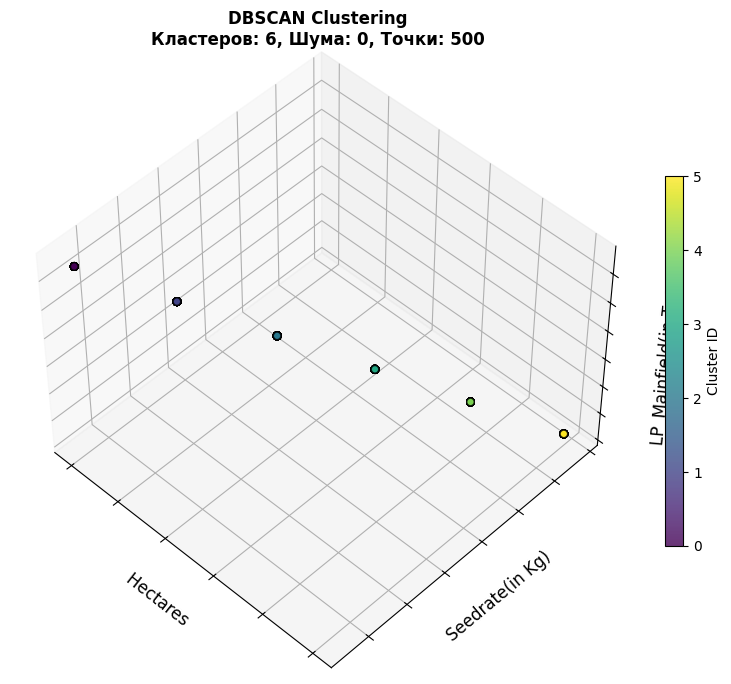

In [45]:
MAX_POINTS = 500
if len(X) > MAX_POINTS:
    sample_idx = np.random.choice(len(X), MAX_POINTS, replace=False)
    if hasattr(X, 'iloc'):
        X_sample = X.iloc[sample_idx]
    else:
        X_sample = X[sample_idx]
    labels_sample = labels[sample_idx]
    print(f"Отображаем {MAX_POINTS} случайных точек из {len(X)}")
else:
    X_sample = X
    labels_sample = labels
    print(f"Отображаем все {len(X)} точек")

if hasattr(X_sample, 'columns'):
    feature_names = X_sample.columns.tolist()
    print(f"Используемые признаки: {feature_names[:3]}")
else:
    feature_names = [f'Feature_{i}' for i in range(3)]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection="3d", elev=48, azim=134)

if hasattr(X_sample, 'iloc'):
    x_coords = X_sample.iloc[:, 0] if X_sample.shape[1] > 0 else X_sample.iloc[:, 0]
    y_coords = X_sample.iloc[:, 1] if X_sample.shape[1] > 1 else X_sample.iloc[:, 0]
    z_coords = X_sample.iloc[:, 2] if X_sample.shape[1] > 2 else X_sample.iloc[:, 1]
else:
    x_coords = X_sample[:, 0] if X_sample.shape[1] > 0 else X_sample[:, 0]
    y_coords = X_sample[:, 1] if X_sample.shape[1] > 1 else X_sample[:, 0]
    z_coords = X_sample[:, 2] if X_sample.shape[1] > 2 else X_sample[:, 1]

scatter = ax.scatter(
    x_coords,
    y_coords,
    z_coords,
    c=labels_sample.astype(float),
    edgecolor="k",
    s=30,
    alpha=0.8,
    cmap='viridis'
)

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

ax.set_xlabel(feature_names[0] if len(feature_names) > 0 else "Feature 1", fontsize=12)
ax.set_ylabel(feature_names[1] if len(feature_names) > 1 else "Feature 2", fontsize=12)
ax.set_zlabel(feature_names[2] if len(feature_names) > 2 else "Feature 3", fontsize=12)

unique_labels = np.unique(labels_sample)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_noise = np.sum(labels_sample == -1)

ax.set_title(f"DBSCAN Clustering\nКластеров: {n_clusters}, Шума: {n_noise}, Точки: {len(X_sample)}",
             fontsize=12, fontweight='bold')

plt.colorbar(scatter, ax=ax, label='Cluster ID', shrink=0.6)

plt.tight_layout()
plt.show()

In [48]:
sample_size = 5000
print(f"Оценка качества кластеризации на {sample_size} точках...")
print("="*60)

if len(X) < sample_size:
    sample_size = len(X)
    print(f"Размер датасета меньше {sample_size}, используем все {len(X)} точек")
    X_small = X
    labels_small = labels
    idx = np.arange(len(X))
else:
    np.random.seed(42)
    idx = np.random.choice(len(X), sample_size, replace=False)

    if hasattr(X, 'iloc'):
        X_small = X.iloc[idx]
    else:
        X_small = X[idx]

    labels_small = labels[idx]

print(f"Размер выборки: {len(X_small)} точек")

try:
    sil = metrics.silhouette_score(X_small, labels_small)
    print(f"\nSilhouette Score: {sil:.4f}")

    if sil > 0.5:
        print(f"  ✓ Отличная кластеризация (силуэт > 0.5)")
    elif sil > 0.3:
        print(f"  ✓ Хорошая кластеризация (силуэт > 0.3)")
    elif sil > 0.1:
        print(f"  ⚠ Средняя кластеризация (силуэт > 0.1)")
    else:
        print(f"  ✗ Слабая кластеризация (силуэт < 0.1)")

except Exception as e:
    print(f"Ошибка при вычислении Silhouette Score: {e}")
    sil = None

if y is not None:
    try:
        if hasattr(y, 'iloc'):
            y_small = y.iloc[idx] if len(y) > sample_size else y
        else:
            y_small = y[idx] if len(y) > sample_size else y

        ari = metrics.adjusted_rand_score(y_small, labels_small)
        print(f"\nAdjusted Rand Index (ARI): {ari:.4f}")

        if ari > 0.7:
            print(f"  ✓ Отличное совпадение с истинными метками (ARI > 0.7)")
        elif ari > 0.4:
            print(f"  ✓ Хорошее совпадение (ARI > 0.4)")
        elif ari > 0.1:
            print(f"  ⚠ Слабое совпадение (ARI > 0.1)")
        else:
            print(f"  ✗ Почти случайное совпадение (ARI < 0.1)")

    except Exception as e:
        print(f"Ошибка при вычислении ARI: {e}")
else:
    print(f"\nARI не вычислен (истинные метки 'y' отсутствуют)")

Оценка качества кластеризации на 5000 точках...
Размер датасета меньше 2789, используем все 2789 точек
Размер выборки: 2789 точек

Silhouette Score: 1.0000
  ✓ Отличная кластеризация (силуэт > 0.5)

Adjusted Rand Index (ARI): -0.0006
  ✗ Почти случайное совпадение (ARI < 0.1)
